In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [19]:

df = pd.read_csv('Iris.csv')

print('Ukuran dataset:', df.shape)
print()
df.head()

Ukuran dataset: (150, 6)



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [20]:

# Cek informasi umum
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [21]:

# Cek nilai null
print('=== CEK MISSING VALUES ===')
print(df.isnull().sum())
print()
print('Total missing values:', df.isnull().sum().sum())


=== CEK MISSING VALUES ===
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Total missing values: 0


=== DISTRIBUSI KELAS ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Setosa = bunga kecil
Versicolor = bunga sedang
Virginica = bunga besar


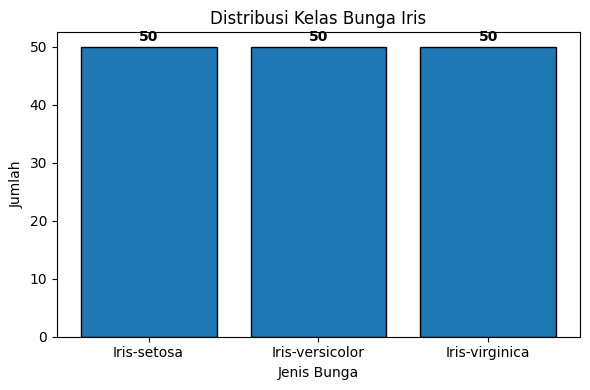

In [22]:

# Distribusi kelas target
print('=== DISTRIBUSI KELAS ===')
print(df['Species'].value_counts())
print()

print('Setosa = bunga kecil')
print('Versicolor = bunga sedang')
print('Virginica = bunga besar')

# Ambil jumlah tiap kelas
counts = df['Species'].value_counts()

# Visualisasi
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, edgecolor='black')
plt.title('Distribusi Kelas Bunga Iris')
plt.xlabel('Jenis Bunga')
plt.ylabel('Jumlah')

# Tambahin angka di atas bar
for i, v in enumerate(counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Preprocessing Data

**Kenapa perlu preprocessing**? Dataset ini semua kolomnya berupa **kategori** (huruf), sedangkan KNN hanya bisa bekerja dengan **angka**. Kita perlu mengubah semua kolom kategori ke angka menggunakan **Label Encoding**.

In [23]:

# Label Encoding: ubah semua kolom kategorik ke numerik
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Encoding selesai! Contoh hasil:')
print(df_encoded.head())

Encoding selesai! Contoh hasil:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   0              8            14              4             1        0
1   1              6             9              4             1        0
2   2              4            11              3             1        0
3   3              3            10              5             1        0
4   4              7            15              4             1        0


In [26]:

# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop('Species', axis=1)   # semua kolom kecuali 'class'
y = df_encoded['Species']                # kolom target: 0=edible, 1=poisonous

print('Bentuk X (fitur):', X.shape)
print('Bentuk y (target):', y.shape)
print()
print('Nilai unik y:', y.unique(), '→ 0=edible, 1=poisonous')

Bentuk X (fitur): (150, 5)
Bentuk y (target): (150,)

Nilai unik y: [0 1 2] → 0=edible, 1=poisonous


In [27]:

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Jumlah data training:', X_train.shape[0])
print('Jumlah data testing :', X_test.shape[0])

Jumlah data training: 120
Jumlah data testing : 30


In [28]:

# Buat dan latih model KNN dengan K=5
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print('Model KNN berhasil dilatih dengan K=5')

Model KNN berhasil dilatih dengan K=5


In [30]:

# Prediksi data test
y_pred = model.predict(X_test)

# Akurasi
acc = accuracy_score(y_test, y_pred)
print('=== HASIL EVALUASI ===')
print(f'Akurasi: {acc * 100:.2f}%')
print()

# Classification Report
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))

=== HASIL EVALUASI ===
Akurasi: 100.00%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



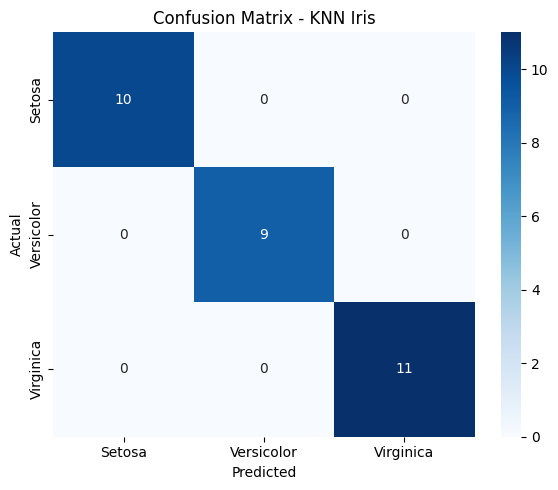

In [31]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])

plt.title('Confusion Matrix - KNN Iris')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

=== HASIL OPTIMASI K ===
K terbaik: 1
Akurasi terbaik: 100.00%


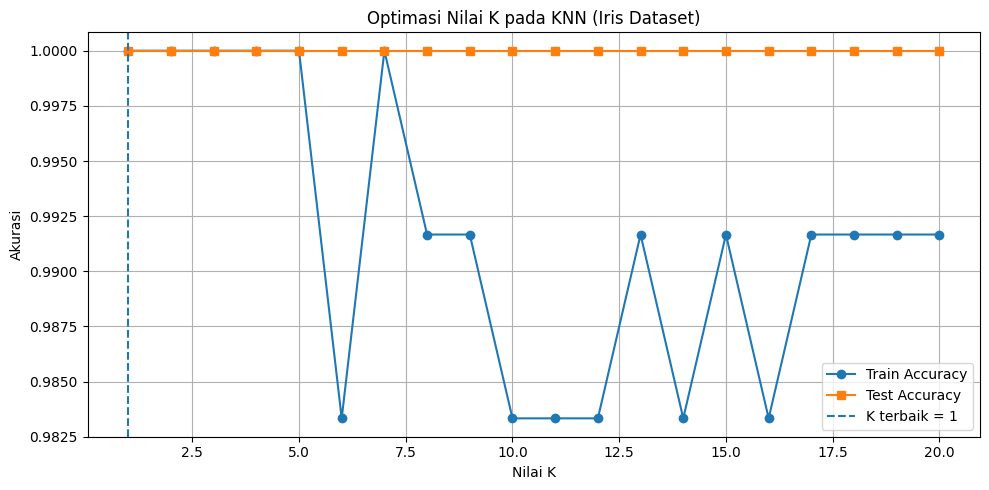

In [32]:
# Coba K dari 1 sampai 20
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))

    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Ambil K terbaik
best_k = k_range[test_scores.index(max(test_scores))]
best_acc = max(test_scores)

print('=== HASIL OPTIMASI K ===')
print(f'K terbaik: {best_k}')
print(f'Akurasi terbaik: {best_acc * 100:.2f}%')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, marker='o', label='Train Accuracy')
plt.plot(k_range, test_scores, marker='s', label='Test Accuracy')
plt.axvline(x=best_k, linestyle='--', label=f'K terbaik = {best_k}')

plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Optimasi Nilai K pada KNN (Iris Dataset)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# Ambil 1 baris dari data test sebagai contoh
contoh = X_test.iloc[[0]]

prediksi = model.predict(contoh)
probabilitas = model.predict_proba(contoh)

# Daftar nama kelas
kelas = model.classes_

print('=== HASIL PREDIKSI ===')
print(f'Prediksi jenis bunga: {prediksi[0]}')
print()

# Tampilkan probabilitas tiap kelas
for i, k in enumerate(kelas):
    print(f'Probabilitas {k}: {probabilitas[0][i]*100:.1f}%')

=== HASIL PREDIKSI ===
Prediksi jenis bunga: 1

Probabilitas 0: 0.0%
Probabilitas 1: 100.0%
Probabilitas 2: 0.0%


| Langkah       | Keterangan                                                                                    |
| ------------- | --------------------------------------------------------------------------------------------- |
| Dataset       | 150 data bunga iris, 4 fitur numerik (sepal & petal), 3 kelas (Setosa, Versicolor, Virginica) |
| Preprocessing | Tidak perlu encoding (data sudah numerik), opsional normalisasi                               |
| Split         | 80% data train, 20% data test                                                                 |
| Model         | KNN (n_neighbors=5)                                                                      |
| Evaluasi      | Accuracy, Precision, Recall, Confusion Matrix                                                 |
| Tuning        | Uji nilai K (1–20) untuk cari K terbaik                                                       |

Dataset ini menggunakan fitur numerik sehingga secara teoritis perhitungan jarak pada algoritma KNN dapat langsung dilakukan tanpa transformasi kategorikal. Namun, dalam praktik yang lebih optimal, normalisasi seperti StandardScaler dapat digunakan untuk menyamakan skala antar fitur agar tidak terjadi dominasi variabel tertentu dalam perhitungan jarak